## Day 22 Classification

Initially we looked at unsupervised classification, where the model inherently finds clusters within the properties of sources. But if we have labels for some of these data points (e.g the object is tall, short, red or blue) then we can use this information to develop a relationship between the label and the properties of the source. This is Supervised classification.


### Supervised Classification

Supervised classification takes a set of features and relates them to predefined sets of classes. (We looked at choosing the optimal set of features in dimensionality reduction).

We ensure that we have a set of predetermined labels assigned to the sections of data we are investigating.

#### Generative vs Discriminative Classification 

1. **Generative:** If we want to know which category is more likely to generate an observed result, then we are using density estimation for classification. And this it **generative classification**. Here, we have a full model for the density of each class, **or** we have a model which describes how the data can be generated from each class.

Instead of drawing lines to segement different groups, the generative model would instead find how each class generates its data. For example, if we are thinking of trying to separate bananas from apples, the model would learn everything about what the fruits look like, geometry, colour, etc and find how probable it is that the banana model generated this fruit rather than a apple model.

2. **Discriminative** This doesn't care about the full distribution and instead defines boundaries. So in our above case, it would be like knowing that an average apple is this long, and a banana is this long and from that determining which class it belongs to.

For example look at the figure below.

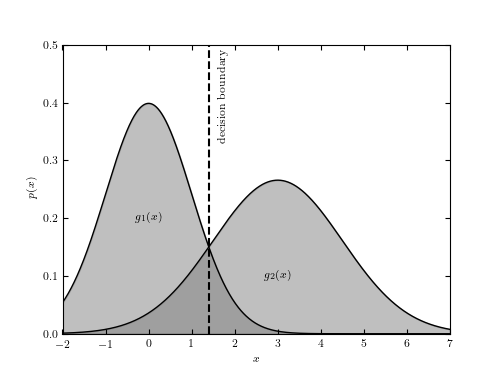

If we look at the figure above, we can see the two different classifications at work. Within generative classification evaluates both models and asks which curve is higher (say for $x=1$) and since $g_1(x) > g_2(x)$, it would pick that one. Whereas discriminative classification would just ask if the point is before or after the boundary.


### First let us look at how to assess results

**Why is this important?**

Well,
- If your data set is imbalanced, such as finding 100 quasars among 10,000 stars, the 10,000 stars will dictate the overall score and miss all the rare targets.
- A small false positive rate can cause large ussyes when the background noise outweighs the target signal

The errors can come from
- False positives, where we assign a true class label when it is really false (Type 1 error)
- False negative, where we do not assign the class label, when it is really true (Type 2 error)

For these, we can define the following terms:

$${\rm completeness} = \frac{\rm true\ positives}{\rm true\ positives + false\ negatives} = {\rm true\ positive\ rate\ /\ sensitivity\ /\ recall}$$

$${\rm contamination} = \frac{\rm false\ positives}{\rm true\ positives + false\ positives} = {\rm false\ discovery\ rate}$$

OR

$${\rm true\ positive\ rate} = \frac{\rm true\ positives} {\rm true\ positives + false\ negatives}$$

$${\rm false\ positive\ rate} = \frac{\rm false\ positives} {\rm true\ negatives + false\ positives} = {\rm Type 1\ error}$$

Where efficiency is:

$${\rm efficiency} = 1 - {\rm contamination} = {\rm precision}.$$

So we want to either maximise the completeness, efficiency or a combination of them.

### Compare performance of classifiers

The different models are evaluated using diagnostic curves by adjusting the classification threshold. 

An **ROC** curve plots the true positive vs false positive rate
- However, these are sensitive to the overall sample size
- So when there are many more background events than source events, we can plot completeness versus efficiency as the false positives would have dominated the signal


Lets look at some curves relating to this. We are comparing 7 different classifiers with a generic clf object, making training and test sets with split_samples and then using the tools to generate our plots.





In [39]:
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

GaussianNB
LinearDiscriminantAnalysis
QuadraticDiscriminantAnalysis
LogisticRegression
KNeighborsClassifier
DecisionTreeClassifier
GMMBayes


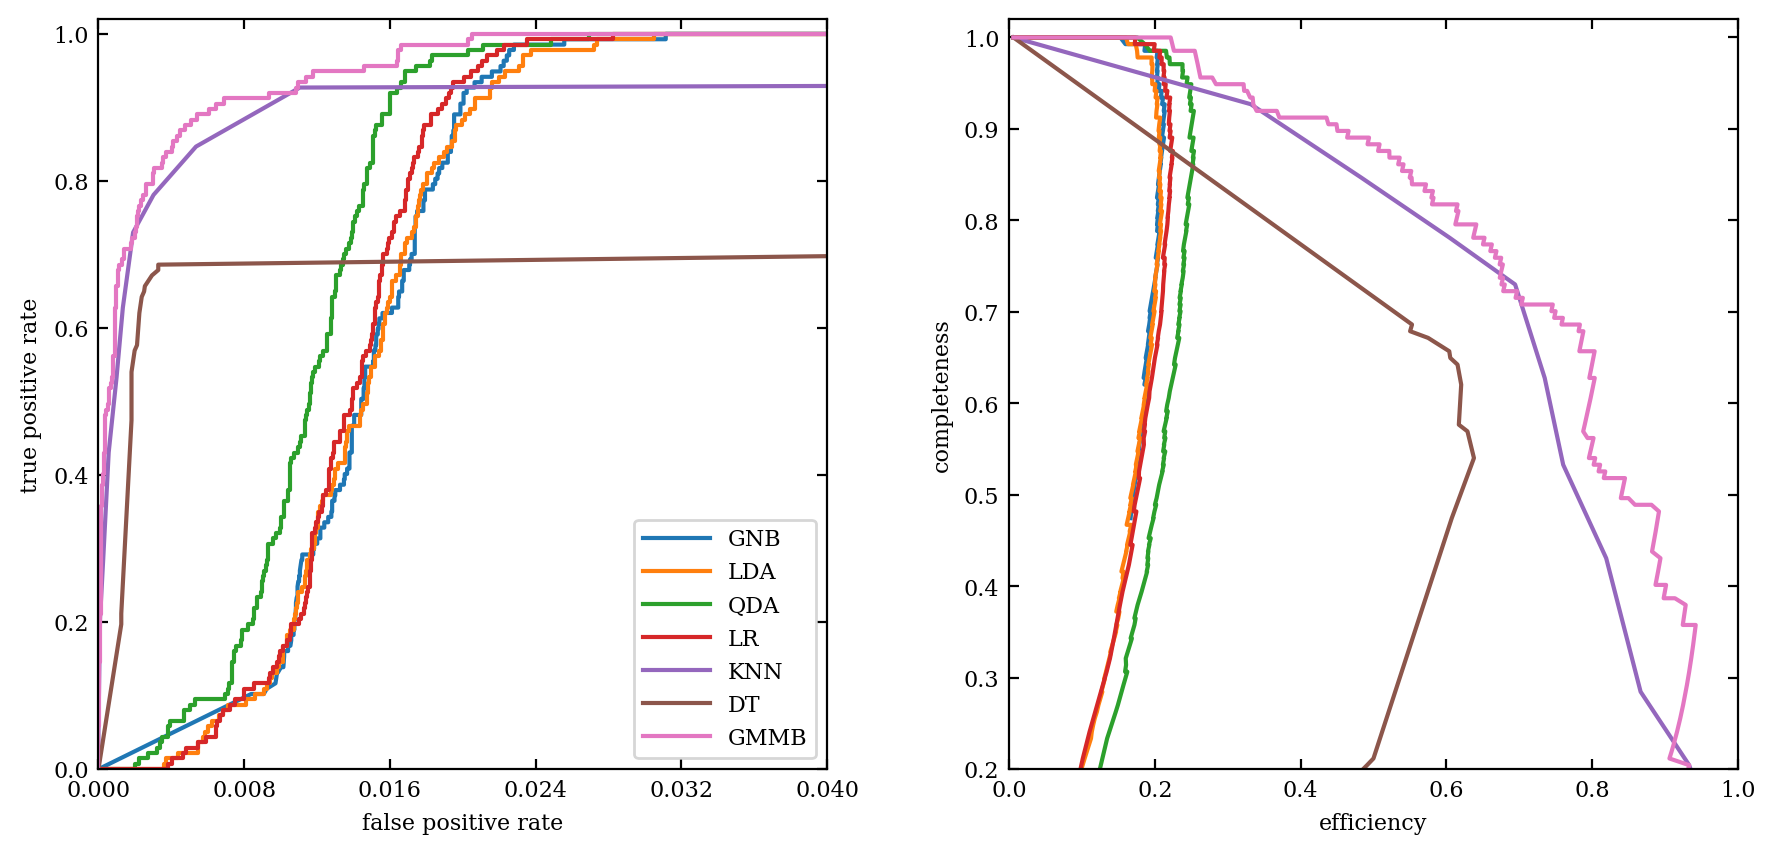

In [40]:
# Ivezic v2, Figure 9.17, edits by GTR
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general

# Edits by Davide Gerosa

from __future__ import print_function

import numpy as np
from matplotlib import pyplot as plt

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis,
                                           QuadraticDiscriminantAnalysis)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from astroML.classification import GMMBayes

from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve

from astroML.utils import split_samples, completeness_contamination
from astroML.datasets import fetch_rrlyrae_combined

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

#----------------------------------------------------------------------
# get data and split into training & testing sets
X, y = fetch_rrlyrae_combined()
y = y.astype(int)
(X_train, X_test), (y_train, y_test) = split_samples(X, y, [0.75, 0.25],
                                                     random_state=0)


#------------------------------------------------------------
# Fit all the models to the training data
def compute_models(*args):
    names = []
    probs = []
    for classifier, kwargs in args:
        print(classifier.__name__)
        clf = classifier(**kwargs)
        clf.fit(X_train, y_train)
        
        #Note that we are outputing the probabilities [of class 1], not the classes
        y_probs = clf.predict_proba(X_test)[:, 1]

        names.append(classifier.__name__)
        probs.append(y_probs)

    return names, probs


names, probs = compute_models((GaussianNB, {}),
                              (LinearDiscriminantAnalysis, {}),
                              (QuadraticDiscriminantAnalysis, {}),
                              (LogisticRegression,
                               dict(class_weight='balanced')),
                              (KNeighborsClassifier,
                               dict(n_neighbors=10)),
                              (DecisionTreeClassifier,
                               dict(random_state=0, max_depth=12,
                                    criterion='entropy')),
                              (GMMBayes, dict(n_components=3, tol=1E-5,
                                              covariance_type='full')))

#------------------------------------------------------------
# Plot ROC curves and completeness/efficiency
fig = plt.figure(figsize=(15, 5))
fig.subplots_adjust(left=0.1, right=0.95, bottom=0.15, top=0.9, wspace=0.25)

# ax1 will show roc curves
ax1 = plt.subplot(131)

# ax2 will show completeness/efficiency
ax2 = plt.subplot(132)

# ax3 will show precision/recall
# ax3 = plt.subplot(133)

labels = dict(GaussianNB='GNB',
              LinearDiscriminantAnalysis='LDA',
              QuadraticDiscriminantAnalysis='QDA',
              KNeighborsClassifier='KNN',
              DecisionTreeClassifier='DT',
              GMMBayes='GMMB',
              LogisticRegression='LR')

thresholds = np.linspace(0, 1, 1001)[:-1]

# iterate through and show results
for name, y_prob in zip(names, probs):
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    precision, recall, thresh2 = precision_recall_curve(y_test, y_prob)

    # add (0, 0) as first point
    fpr = np.concatenate([[0], fpr])
    tpr = np.concatenate([[0], tpr])
    # Here we add (1,0) 
    precision = np.concatenate([[0], precision])
    recall = np.concatenate([[1], recall])
    thresh2 = np.concatenate([[0], thresh2])

    ax1.plot(fpr, tpr, label=labels[name])

    #See note above about astroML vs. sklearn
    #Note that the range of threshhold values here is 0% to 100% (0.0 to 1.0)
    comp = np.zeros_like(thresholds)
    cont = np.zeros_like(thresholds)
    for i, t in enumerate(thresholds):
        y_pred = (y_prob >= t)
        comp[i], cont[i] = completeness_contamination(y_pred, y_test)
    ax2.plot(1 - cont, comp, label=labels[name])
    
    #ax3.plot(precision, recall, label=labels[name])

ax1.set_xlim(0, 0.04)
ax1.set_ylim(0, 1.02)
ax1.xaxis.set_major_locator(plt.MaxNLocator(5))
ax1.set_xlabel('false positive rate')
ax1.set_ylabel('true positive rate')
ax1.legend(loc=4)

ax2.set_xlabel('efficiency')
ax2.set_ylabel('completeness')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(0.2, 1.02)

#ax3.set_xlabel('precision')
#ax3.set_ylabel('recall')
#ax3.set_xlim(0, 1.0)
#ax3.set_ylim(0.2, 1.02)

plt.show()

The plot below shows completeness vs efficiency as a function of the threshold values. It is also highlighted where the precision is 90%.



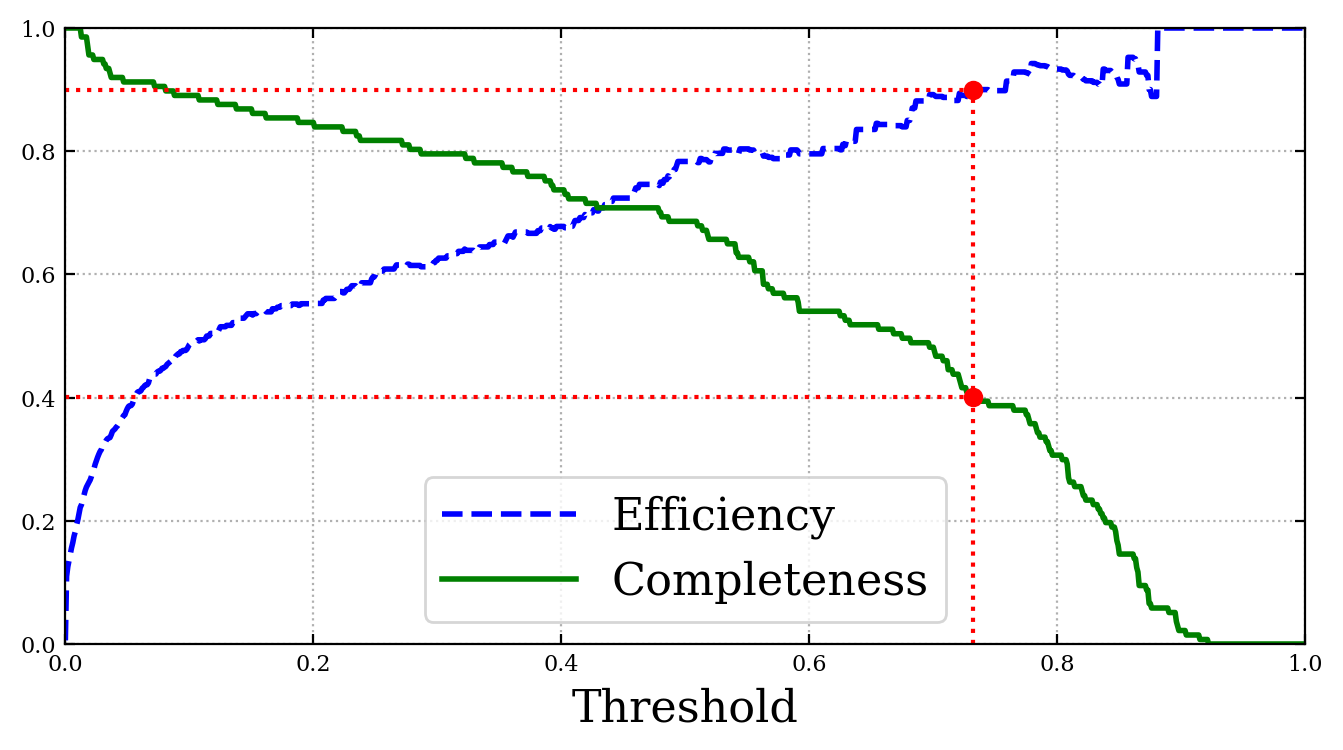

In [41]:
eff = 1-cont
def plot_comp_eff_vs_threshold(eff, comp, thresholds):
    plt.plot(thresholds, eff, "b--", label="Efficiency", linewidth=2)
    plt.plot(thresholds, comp, "g-", label="Completeness", linewidth=2)
    plt.legend(loc="best", fontsize=16)
    plt.xlabel("Threshold", fontsize=16)
    plt.grid(True)                
    plt.axis([0, 1, 0, 1])             

comp_90_eff = comp[np.argmax(eff >= 0.90)]
threshold_90_eff = thresholds[np.argmax(eff >= 0.90)]

plt.figure(figsize=(8, 4))                                                                  
plot_comp_eff_vs_threshold(eff, comp, thresholds)
plt.plot([threshold_90_eff, threshold_90_eff], [0., 0.9], "r:")                 
plt.plot([0, threshold_90_eff], [0.9, 0.9], "r:")                                
plt.plot([0, threshold_90_eff], [comp_90_eff, comp_90_eff], "r:")
plt.plot([threshold_90_eff], [0.9], "ro")                                             
plt.plot([threshold_90_eff], [comp_90_eff], "ro")                                                                          
plt.show()

This is only binary classification so far, later i should have a look into Multiclass and Multilabel.

### Generative Classification

We model the feature distribution for each class, $p(\mathbf{x}\mid y_k)$, then use Bayes' theorem to obtain the posterior class probabilities $p(y_k\mid \mathbf{x})$.

For $N$ data points with $D$ features,

$$
\mathbf{x}_i = (x_i^1,\ldots,x_i^D),
$$

where $x_i^j$ is the $j$-th feature of observation $i$. With $K$ classes, $y_k$ denotes class $k$.

> For an example, $x_i$ may be an object with several measured features like colour, brightness and size
>
> Then we have the possible classes $y_k$ thay say it is a star or a galaxy

Bayes' theorem gives

$$
p(y_k\mid \mathbf{x}_i)
=
\frac{p(\mathbf{x}_i\mid y_k)\,p(y_k)}
{\sum_{k'} p(\mathbf{x}_i\mid y_{k'})\,p(y_{k'})}.
$$

Where the likelihood says if it was really in class k, how plausible would these features be. The prior wonders how common class k is before looking at the object. And the posterior sees the features and determines how likely k is.

#### Discriminant Function

We can relate classification to density estimation and regression, where

$$
\hat{y} = f(y|x)
$$

represents the best guess of $y$ given $x$.

We can think of Classification as regression with discrete $y$ values.

Where if we wish to learn whether an object is a star or galaxy using a single feature, say colour, then the classifier would learn a function like

$$
g(x) = P(y=1|x)
$$

So we can see that $g(x)$ shows the probability of an object with colour $x$ being a star.

If we take

$$
y=1 \quad \text{for a star}
$$

and

$$
y=0 \quad \text{for a galaxy},
$$

then

$$
\begin{aligned}
g(x)
&= f(y|x) \\
&= \sum_y y\,p(y|x) \\
&= 1\cdot p(y=1|x) + 0\cdot p(y=0|x) \\
&= p(y=1|x)
\end{aligned}
$$

The first equation is finding the expected value of $y$ given $x$. Since $y$ is discrete here, we use a sum over the possible values of $y$.

So if $g(x)=0.8$, our best prediction is that there is an $80\%$ probability that the object is a star.

We can then use Bayes' rule:

$$
g(x)
=
\frac{p(x|y=1)\,p(y=1)}
{p(x|y=1)\,p(y=1)+p(x|y=0)\,p(y=0)}
$$

This links classification back to density estimation, as we first model the density of the features for each class, $p(x|y)$, and then use Bayes' theorem to find the probability of each class given the observed features.



### Bayes Classifier

If the discriminant function gives a binary prediction, it is known as the Bayes classifier, so if we use a Bayes classifier that says:

$$
\hat{y}
=
\begin{cases}
1, & \text{if } g(x) > \frac{1}{2}, \\
0, & \text{otherwise}.
\end{cases}
$$

Since

$$
g(x)=p(y=1|x),
$$

this can also be written as

$$
\hat{y}
=
\begin{cases}
1, & \text{if } p(y=1|x) > p(y=0|x), \\
0, & \text{otherwise}.
\end{cases}
$$

So the Bayes classifier simply chooses the class with the largest posterior probability.


### Decision boundary

A decision boundary is a set of x values at which each class is equally likely, we can look at the figure we had previously and see where the decision boundary is. It is written as:

$$p(x|y=1)p(y=1)  =  p(x|y=0)p(y=0);$$

$$g_1(x) = g_2(x) \; {\rm or}\; g(x) = 1/2$$

### Naive Bayes

When doing classification, it gets more complex as we are usually have data that is multi dimensional. Hence we have $x^{j=0},x^1,x^2,x^3...x^N$ and want $p(x^0,x^1,x^2,x^3...x^N|y)$

This is for discrete, not continuous, features. And we assume all attributes are conditionally independent, so our multi dimensional pdfs can simplify to:

$$p(x^i,x^j|y_k) = p(x^i|y_k)p(x^j|y_k)$$

Rewriting this gives:

$$p({x^{j=0},x^1,x^2,\ldots,x^N}|y_k) = \prod_j p(x^j|y_k).$$

Use Bayes' rule and conditional independence to swap the terms:

$$p(y_k | {x^0,x^1,\ldots,x^N}) =
  \frac{\prod_j p(x^j|y_k) p(y_k)}
       {\sum_l \prod_j p(x^j|y_l) p(y_l)}.$$

And then we calculate the most likely value of $y$ by maximising this over choices of $y_k$

$$\hat{y} = \arg \max_{y_k} \frac{\prod_j p(x^j|y_k) p(y_k)}
        {\sum_l \prod_j p(x^j|y_l) p(y_l)},$$

From here we just estimate densities. $p(x|y=y_k)$ and $p(y=y_k)$ are learned from a set of training data where,

-   $p(y=y_k)$ is the frequency of class $k$
-   $p(x|y=y_k)$ is the density of an object with class k having the attributes x.

### Gaussian Naive Bayes

So that's for discrete data, what about continuous data?

We instead model $p(x^j|y=y_k)$ as one dimensional normal distributions with a mean $\mu^j_k$ and widths $\sigma_k^j$. Then our Naive bayes estimator becomes:

$$\hat{y} = \arg\max_{y_k}\left[\ln p(y=y_k) - \frac{1}{2}\sum_{j=1}^D\left(  \ln \left[2\pi(\sigma^j_k)^2\right] + \frac{(x^j - \mu^j_k)^2}{(\sigma^j_k)^2} \right) \right]$$

This is how Gaussian Naive Bayes classification is implemented:



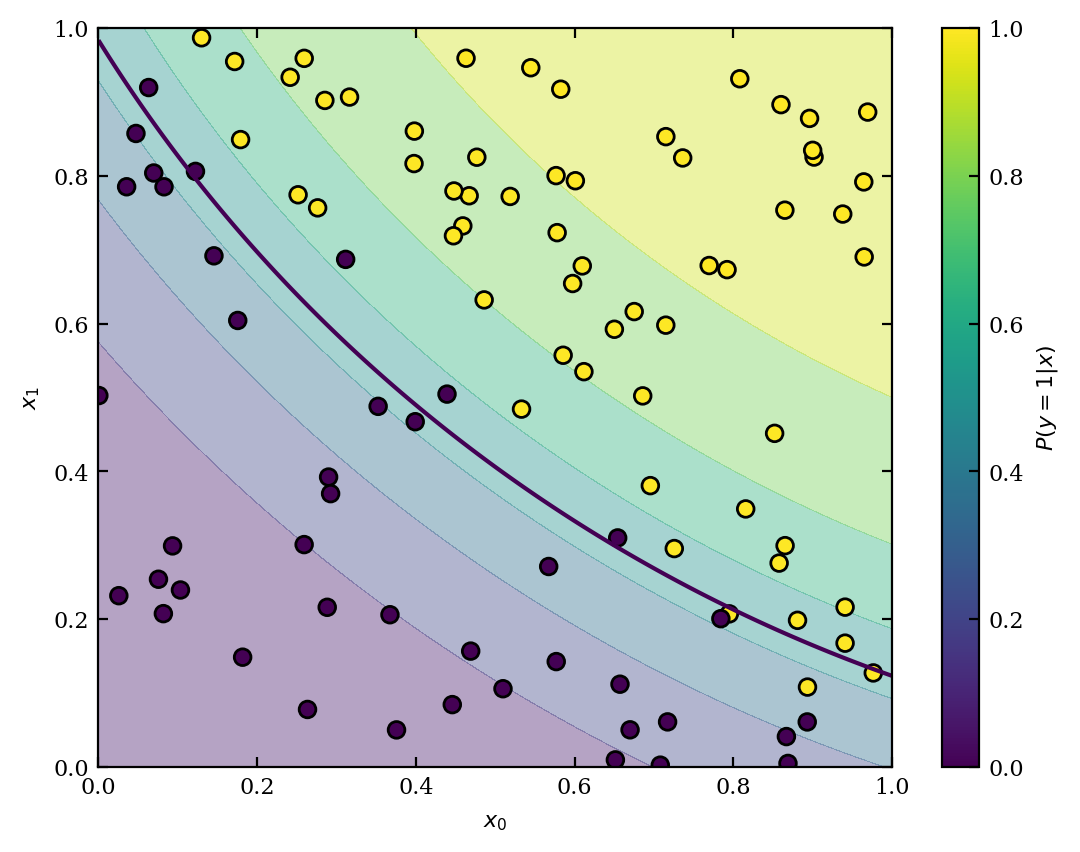

In [42]:
import numpy as np
from sklearn.naive_bayes import GaussianNB

X = np.random.random((100, 2))
y = (X[:, 0] + X[:, 1] > 1).astype(int) # Class 1 if sum of both features is greater than 1

gnb = GaussianNB().fit(X, y)

# Grid of points
xx, yy = np.meshgrid(
    np.linspace(0, 1, 200),
    np.linspace(0, 1, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
prob = gnb.predict_proba(grid)[:, 1].reshape(xx.shape)

# Plot probability and decision boundary
plt.contourf(xx, yy, prob, alpha=0.4)
plt.contour(xx, yy, prob, levels=[0.5])

plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="black")

plt.xlabel("$x_0$")
plt.ylabel("$x_1$")
plt.colorbar(label="$P(y=1|x)$")

plt.show()

Here our purple dots are class 0 and the yellow dots are class 1. 

The purple line shows the decision boundary between $P(y=1 | x) = 0.5$


Now an example from the book:

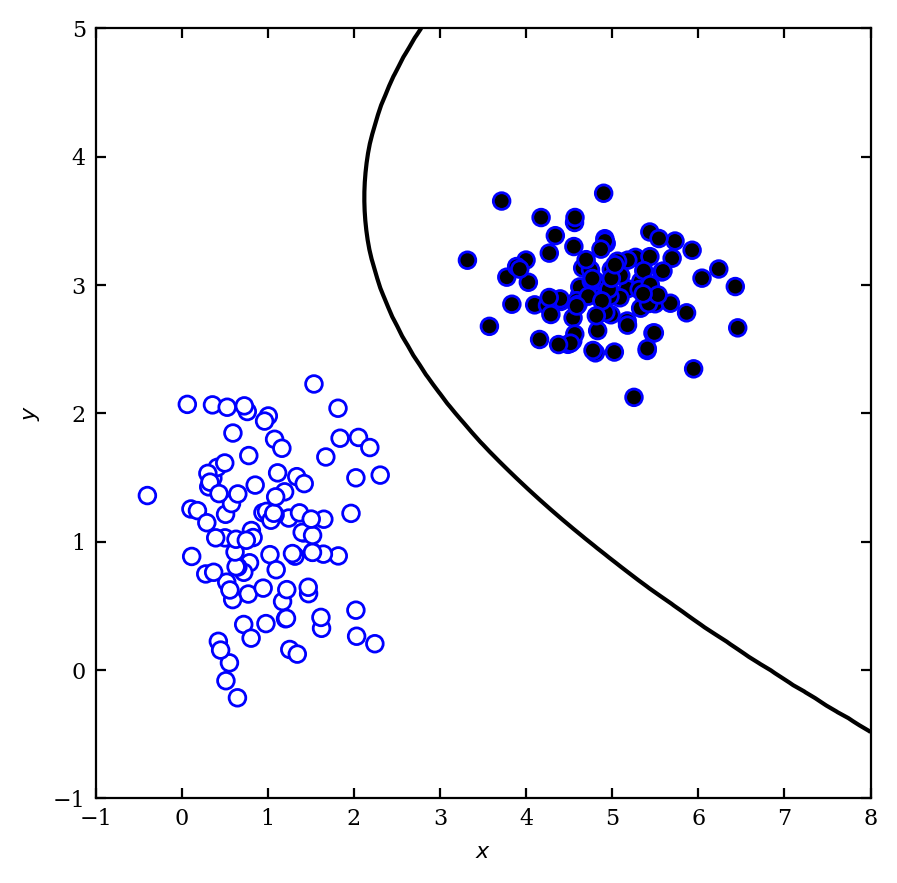

In [43]:
# Ivezic v2, Figure 9.2, edits by GTR and SRT
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from matplotlib import colors

from sklearn.naive_bayes import GaussianNB

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

#------------------------------------------------------------
# Simulate some data
np.random.seed(0)
mu1 = [1, 1]
cov1 = 0.3 * np.eye(2)

mu2 = [5, 3]
cov2 = np.eye(2) * np.array([0.4, 0.1])

X = np.concatenate([np.random.multivariate_normal(mu1, cov1, 100),
                    np.random.multivariate_normal(mu2, cov2, 100)])
y = np.zeros(200)
y[100:] = 1

#------------------------------------------------------------
# Fit the Naive Bayes classifier
clf = GaussianNB()
clf.fit(X, y)

# predict the classification probabilities on a grid
xlim = (-1, 8)
ylim = (-1, 5)
xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 71),
                     np.linspace(ylim[0], ylim[1], 81))
Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])
# Gives probability for both class 1 and class 2 for each grid point
# As these are degenerate, take just one and then
# re-shape it to the grid pattern needed for contour plotting
Z = Z[:, 1].reshape(xx.shape)

#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)
ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.binary, zorder=2)


# Add the decision boundary, which is just the contour where
# the probability exceeds some threshold, here 0.5.
ax.contour(xx, yy, Z, [0.5], colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

plt.show()

### What if they're not modelled independently?

Then we model the whole feature vector together using multivariate gaussians:

$$p_k(\vec{x}) = \frac{1}{\sqrt{\mathrm{det}(2\pi\Sigma_k)}}\exp\left[ -\frac{1}{2}(\vec{x}-\vec{\mu}_k)^T \Sigma_k^{-1}(\vec{x}-\vec{\mu}_k) \right].$$

here, $\mu_k$ is the centre of class k in the feature space, $\Sigma_k$ is the covariance matrix of class k which allows the features to be correlated.

> Feature space is the space where our axes are our features.

And our Bayesian Bayes classifier becomes:

$$\hat{y} = \arg\max_{y_k}\left[\ln p(y=y_k) - \frac{1}{2}\ln\mathrm{det}(\Sigma_k) - \frac{1}{2}(\vec{x}-\vec{\mu}_k)^T \Sigma_k^{-1}(\vec{x}-\vec{\mu}_k)\right]$$

Allowing us to find the most probable class for the data point.

Where each term asks different questions:

$$
\underbrace{\ln p(y_k)}_{\text{How common is this class?}}
$$

$$
\underbrace{-\frac{1}{2}\ln\det(\Sigma_k)}_{\text{How spread out is this class?}}
$$

$$
\underbrace{
-\frac{1}{2}
(\mathbf{x}-\boldsymbol{\mu}_k)^T
\Sigma_k^{-1}
(\mathbf{x}-\boldsymbol{\mu}_k)
}_{\text{How far is the point from this class?}}
$$


### Linear and Quadratic Discriminant Analysis

We simplify the Gaussian Bayes classifier by assuming that the class distributions have identical covariance for all $k$ classes.

As we are looking at

$$\hat{y} = \arg\max_{y_k}\left[\ln p(y=y_k) - \frac{1}{2}\ln\mathrm{det}(\Sigma_k) - \frac{1}{2}(\vec{x}-\vec{\mu}_k)^T \Sigma_k^{-1}(\vec{x}-\vec{\mu}_k)\right]$$

If we expand the last term, we get

$$
-\frac{1}{2}\mathbf{x}^T\Sigma_k^{-1}\mathbf{x}.
$$

Since the covariances are the same,

$$
-\frac{1}{2}\mathbf{x}^T\Sigma^{-1}\mathbf{x}
$$

THis has the exact same value regardless of which class we are looking at, this is the same for:

$$
-\frac{1}{2}\ln\det(\Sigma)
$$

And since we are doing $\hat y=\arg\max_k g_k(\mathbf{x}), anything that is added equally to every class can not change which class has the higher score, so the only dependence is linear.

So if we were to do this, it would cancel out all the terms with a quadratic dependence on $X$, and so the log of the class posteriors is:

$$g_k(\vec{x}) = \vec{x}^T \Sigma^{-1} \vec{\mu_k} - \frac{1}{2}\vec{\mu_k}^T \Sigma^{-1} \vec{\mu_k} + \ln p(y=y_k),$$

If we relax this requirement that the covariances of the gaussians are equal, we get Quadratic Discriminant Analysis (QDA).

Here is how we implement this:


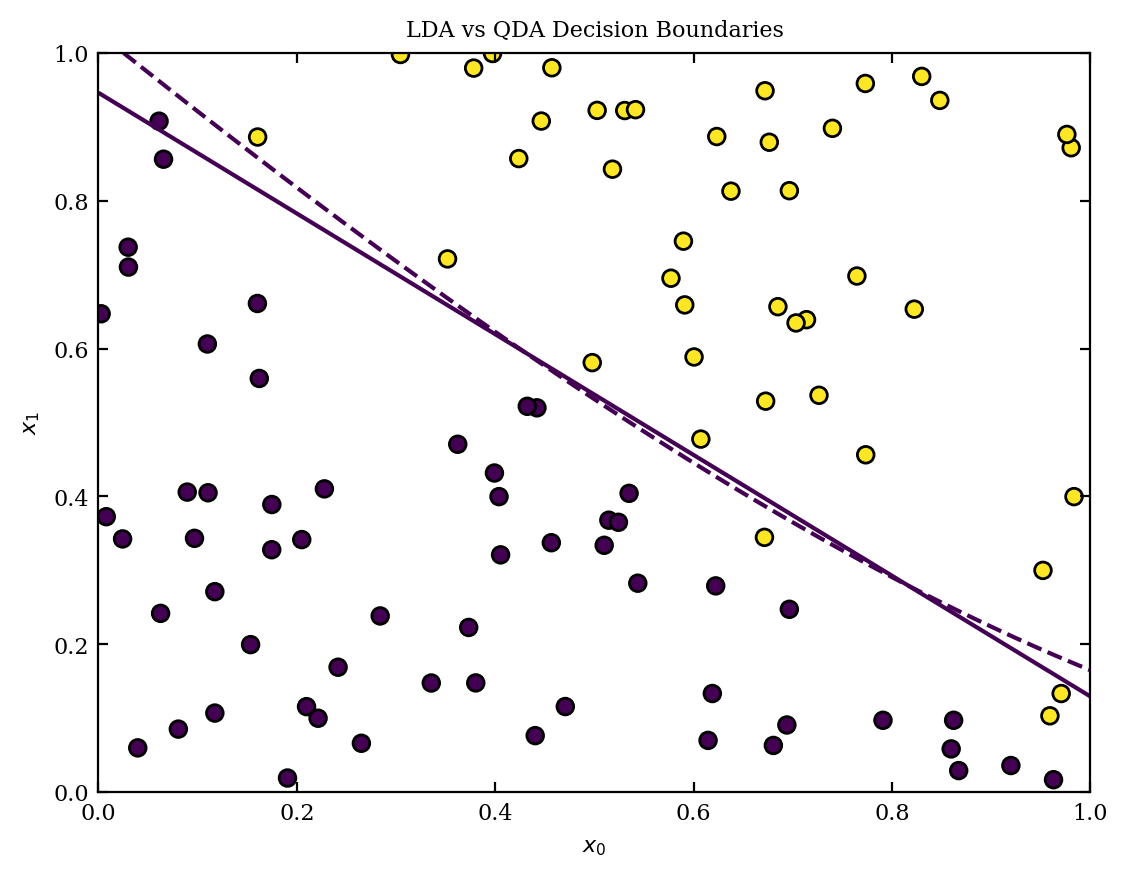

In [44]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

X = np.random.random((100,2))
y = (X[:,0] + X[:,1] > 1).astype(int)

lda = LDA()
lda.fit(X,y)
y_pred = lda.predict(X)

qda = QDA()
qda.fit(X,y)
y_pred = qda.predict(X)

# Grid over feature space
xx, yy = np.meshgrid(
    np.linspace(0, 1, 200),
    np.linspace(0, 1, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

p_lda = lda.predict_proba(grid)[:, 1].reshape(xx.shape)
p_qda = qda.predict_proba(grid)[:, 1].reshape(xx.shape)

# Data
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="black")

# Decision boundaries: P(y=1|x) = 0.5
plt.contour(xx, yy, p_lda, levels=[0.5], linestyles="-")
plt.contour(xx, yy, p_qda, levels=[0.5], linestyles="--")

plt.xlabel("$x_0$")
plt.ylabel("$x_1$")
plt.title("LDA vs QDA Decision Boundaries")

plt.show()

We can see that that the LDA decision boundary is a straight line, whereas for QDA its curved.

We can also use this on an example RR Lyrae data:

completeness 0.6715328467153284 0.6861313868613139
contamination 0.8059071729957806 0.7924944812362031


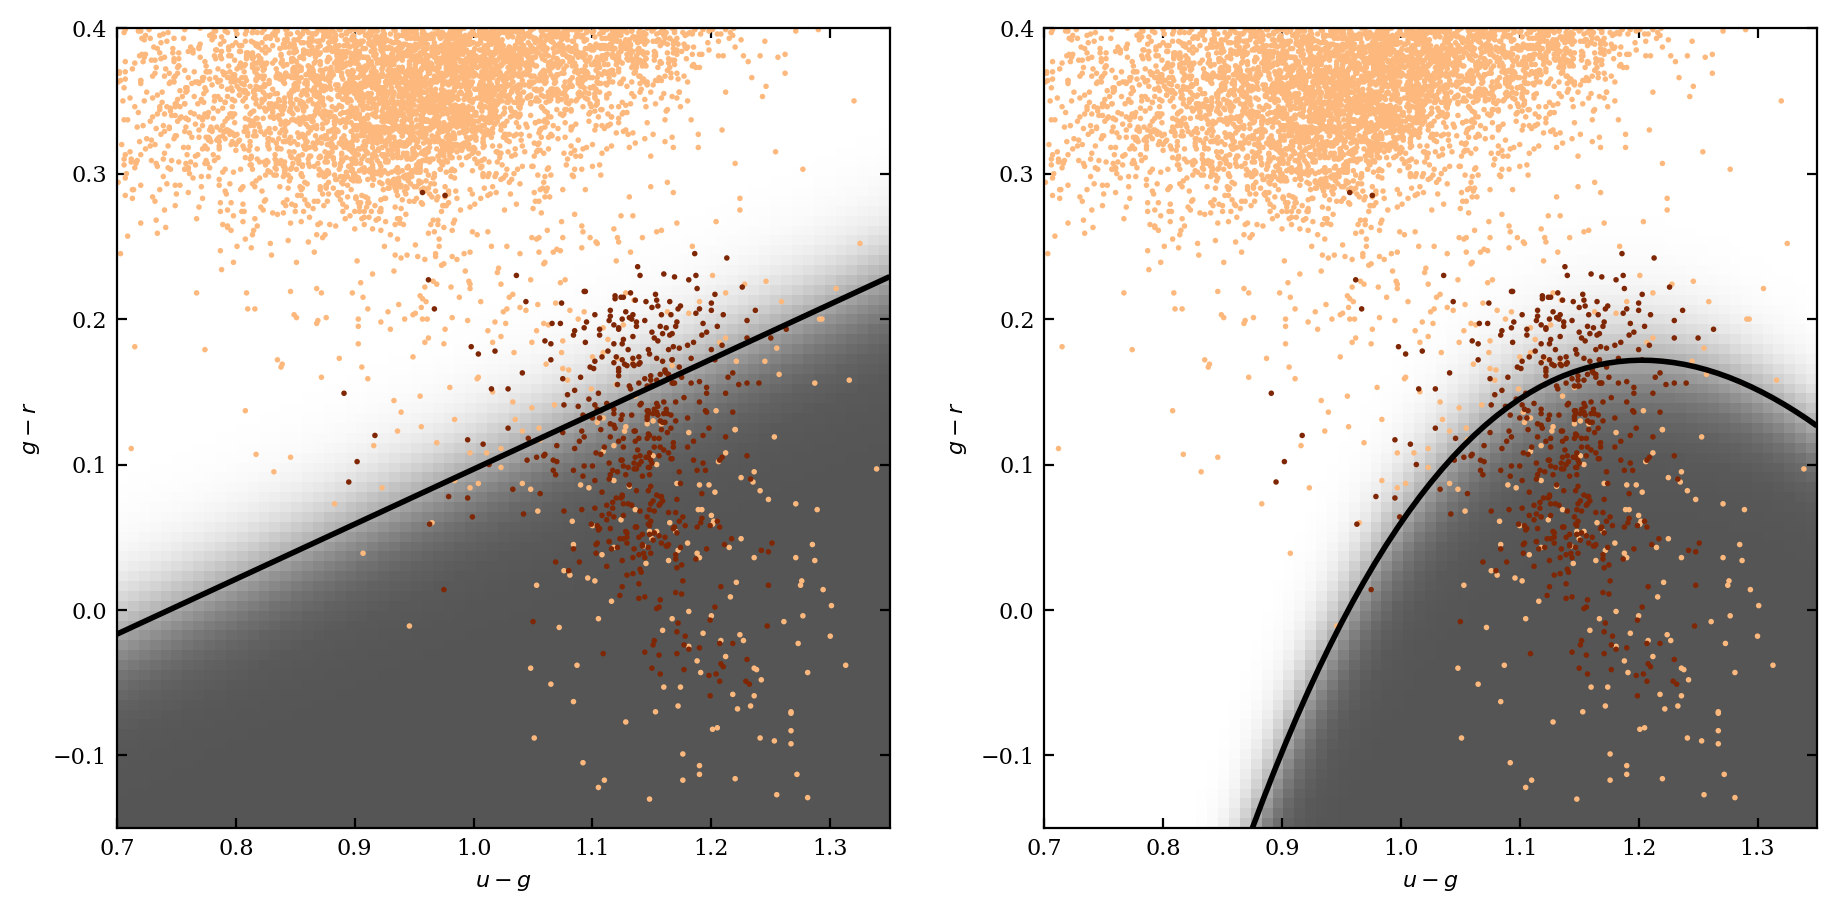

In [45]:
# Ivezic, Figures 9.4 and 9.5, spliced together by GTR

from astroML.datasets import fetch_rrlyrae_combined
from astroML.utils import split_samples
from astroML.utils import completeness_contamination

#----------------------------------------------------------------------
# get data and split into training & testing sets
X, y = fetch_rrlyrae_combined()
X = X[:, [1, 0, 2, 3]]  # rearrange columns for better 1-color results
(X_train, X_test), (y_train, y_test) = split_samples(X, y, [0.75, 0.25], 
                                                     random_state=0)

N_tot = len(y)
N_stars = np.sum(y == 0)
N_rrlyrae = N_tot - N_stars
N_train = len(y_train)
N_test = len(y_test)
N_plot = 5000 + N_rrlyrae

#----------------------------------------------------------------------
# perform LDA
lda = LDA()
lda.fit(X_train[:, :2], y_train)
y_predLDA = lda.predict(X_test[:, :2])

# perform QDA
qda = QDA()
qda.fit(X_train[:, :2], y_train)
y_predQDA = qda.predict(X_test[:, :2])
    
completenessLDA, contaminationLDA = completeness_contamination(y_predLDA, y_test)
completenessQDA, contaminationQDA = completeness_contamination(y_predQDA, y_test)

print("completeness", completenessLDA, completenessQDA)
print("contamination", contaminationLDA, contaminationQDA)

#------------------------------------------------------------
# Compute the decision boundary
xlim = (0.7, 1.35)
ylim = (-0.15, 0.4)

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 71),
                     np.linspace(ylim[0], ylim[1], 81))

Z_LDA = lda.predict_proba(np.c_[yy.ravel(), xx.ravel()])
Z_LDA = Z_LDA[:, 1].reshape(xx.shape)
Z_QDA = qda.predict_proba(np.c_[yy.ravel(), xx.ravel()])
Z_QDA = Z_QDA[:, 1].reshape(xx.shape)

#----------------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(10, 5))
fig.subplots_adjust(bottom=0.15, top=0.95, hspace=0.0,
                    left=0.1, right=0.95, wspace=0.2)

# left plot: data and decision boundary
ax = fig.add_subplot(121)
im = ax.scatter(X[-N_plot:, 1], X[-N_plot:, 0], c=y[-N_plot:],
                s=4, lw=0, cmap=plt.cm.Oranges, zorder=2)
im.set_clim(-0.5, 1)

im = ax.imshow(Z_LDA, origin='lower', aspect='auto',
               cmap=plt.cm.binary, zorder=1,
               extent=xlim + ylim)
im.set_clim(0, 1.5)

ax.contour(xx, yy, Z_LDA, [0.5], linewidths=2., colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')

# right plot: qda
ax = fig.add_subplot(122)
im = ax.scatter(X[-N_plot:, 1], X[-N_plot:, 0], c=y[-N_plot:],
                s=4, lw=0, cmap=plt.cm.Oranges, zorder=2)
im.set_clim(-0.5, 1)

im = ax.imshow(Z_QDA, origin='lower', aspect='auto',
               cmap=plt.cm.binary, zorder=1,
               extent=xlim + ylim)
im.set_clim(0, 1.5)

ax.contour(xx, yy, Z_QDA, [0.5], linewidths=2., colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')

plt.show()

### What if linear or quadratic boundaries won't work?

If each class can't be represented by a single gaussian cloud in the feature space. So maybe we can use a mixture of gaussians through the Gaussian Mixture Model.

We initially had

$$
p(\mathbf{x}\mid y_k)
=
\mathcal{N}(\mathbf{x}\mid \boldsymbol{\mu}_k,\Sigma_k).
$$

If we represent the class as a mixture of several gaussians we instead have:

$$
p(\mathbf{x}\mid y_k)
=
\sum_{j=1}^{K_k}
\pi_{kj}\,
\mathcal{N}
\left(
\mathbf{x}\mid
\boldsymbol{\mu}_{kj},
\Sigma_{kj}
\right).
$$

Where 
- $p(\mathbf{x}\mid y_k)$: Given that the object belongs to class $k$, what distribution do its possible feature vectors $x$ follow
- $K_k$ is the number of gaussian components used to describe class $k$
- $\pi_{jk}$: The weight of the component $j$ in class $k$, hence how much the gaussian contributes to the overall class distribution
- The mean and covariance describe the centre, and the spread, shape and correlations of the Gaussian.



Let's apply the GMM Bayes Classifier to the stellar data we had before:

@pickle_results: using precomputed results from 'GMMbayes_rrlyrae.pkl'
completeness [[0.48175182 0.68613139 0.73722628 0.78832117]
 [0.         0.         0.33576642 0.61313869]]
contamination [[0.85201794 0.79249448 0.77605322 0.75675676]
 [0.         0.         0.11538462 0.25      ]]


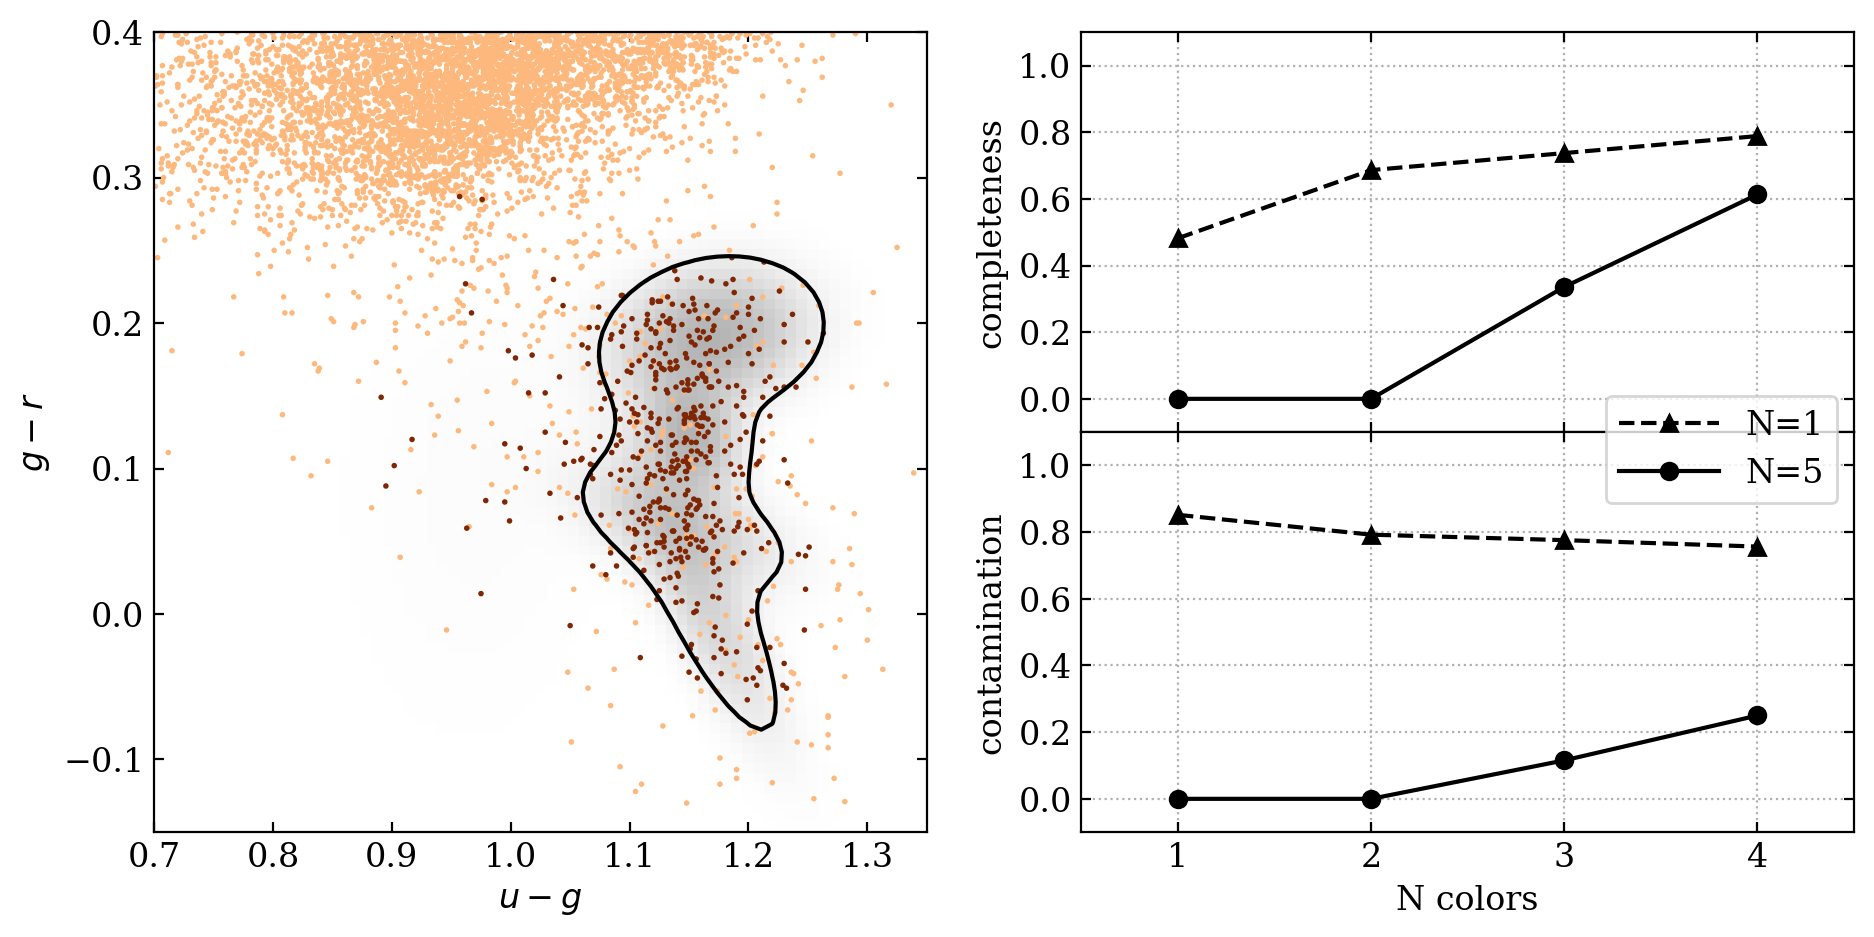

In [46]:
# Ivezic v2, Figure 9.6, edits by GTR and SRT
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from astroML.classification import GMMBayes
from astroML.utils.decorators import pickle_results
from astroML.datasets import fetch_rrlyrae_combined
from astroML.utils import split_samples
from astroML.utils import completeness_contamination

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=12, usetex=False)


#----------------------------------------------------------------------
# get data and split into training & testing sets
X, y = fetch_rrlyrae_combined()
X = X[:, [1, 0, 2, 3]]  # rearrange columns for better 1-color results

# GMM-bayes takes several minutes to run, and is order[N^2]
#  truncating the dataset can be useful for experimentation.
#X = X[::10]
#y = y[::10]

(X_train, X_test), (y_train, y_test) = split_samples(X, y, [0.75, 0.25],
                                                     random_state=0)
N_tot = len(y)
N_st = np.sum(y == 0)
N_rr = N_tot - N_st
N_train = len(y_train)
N_test = len(y_test)
N_plot = 5000 + N_rr

#----------------------------------------------------------------------
# perform GMM Bayes
Ncolors = np.arange(1, X.shape[1] + 1)
Ncomp = [1, 5]


@pickle_results('GMMbayes_rrlyrae.pkl')
def compute_GMMbayes(Ncolors, Ncomp):
    classifiers = []
    predictions = []

    for ncm in Ncomp:
        classifiers.append([])
        predictions.append([])
        for nc in Ncolors:
            clf = GMMBayes(ncm, tol=1E-5, covariance_type='full')
            clf.fit(X_train[:, :nc], y_train)
            y_pred = clf.predict(X_test[:, :nc])

            classifiers[-1].append(clf)
            predictions[-1].append(y_pred)

    return classifiers, predictions

classifiers, predictions = compute_GMMbayes(Ncolors, Ncomp)

completeness, contamination = completeness_contamination(predictions, y_test)

print("completeness", completeness)
print("contamination", contamination)

#------------------------------------------------------------
# Compute the decision boundary
clf = classifiers[1][1]
xlim = (0.7, 1.35)
ylim = (-0.15, 0.4)

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 71),
                     np.linspace(ylim[0], ylim[1], 81))

Z = clf.predict_proba(np.c_[yy.ravel(), xx.ravel()])
Z = Z[:, 1].reshape(xx.shape)

#----------------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(10, 5))
fig.subplots_adjust(bottom=0.15, top=0.95, hspace=0.0,
                    left=0.1, right=0.95, wspace=0.2)

# left plot: data and decision boundary
ax = fig.add_subplot(121)
im = ax.scatter(X[-N_plot:, 1], X[-N_plot:, 0], c=y[-N_plot:],
                s=4, lw=0, cmap=plt.cm.Oranges, zorder=2)
im.set_clim(-0.5, 1)

im = ax.imshow(Z, origin='lower', aspect='auto',
               cmap=plt.cm.binary, zorder=1,
               extent=xlim + ylim)
im.set_clim(0, 1.5)

ax.contour(xx, yy, Z, [0.1], colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')

# plot completeness vs Ncolors
ax = fig.add_subplot(222)
ax.plot(Ncolors, completeness[0], '^--k', ms=6, label='N=%i' % Ncomp[0])
ax.plot(Ncolors, completeness[1], 'o-k', ms=6, label='N=%i' % Ncomp[1])

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.NullFormatter())

ax.set_ylabel('completeness')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

# plot contamination vs Ncolors
ax = fig.add_subplot(224)
ax.plot(Ncolors, contamination[0], '^--k', ms=6, label='N=%i' % Ncomp[0])
ax.plot(Ncolors, contamination[1], 'o-k', ms=6, label='N=%i' % Ncomp[1])
ax.legend(loc='lower right',
          bbox_to_anchor=(1.0, 0.78))

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%i'))

ax.set_xlabel('N colors')
ax.set_ylabel('contamination')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

plt.show()

Here, we can take it to the extreme by having a gaussian mixture component at each training point. We also can use different kernels, and the resulting non parametric bayes classifier is known as Kernel Discriminant Analysis.


### K - Nearest Neighbour Classifier

So far with LDA, each class was gaussian and all classes shared the same covariance. With QDA, each class is one Gaussian but each class gets its own covariance. With GMM Bayes, each class is made up of several gaussians.

**KDA** takes this a little further, instead of a small number of Gaussian components, we instead put a kernel at every training point. Such that

$$
p(\mathbf{x}\mid y_k)
\approx
\frac{1}{N_k}
\sum_{i:y_i=k}
K(\mathbf{x}-\mathbf{x}_i)
$$

This is now non-parametric as we aren't assuming the class follows a fixed shape. Then if we use a variable bandwidth that depends only on the distance of the nearest neighbour, then we get the Nearest-Neighbour classifier. If a point $x$ is close to another training point $x'$, then

$$
p(y\mid \mathbf{x})
\approx
p(y\mid \mathbf{x}')
$$

We use the class label of the nearest point

- Larger $K$ neighbours decreases the variance in the classification but increases bias

In simple terms, the majority rule classification is adopted where each of the $K$ neighbours votes on the classification

The distance measured is usually N-dimensional Euclidean, but if the attributes have very different properties then normalisation, weighting etc may be needed.

Lets implement this:

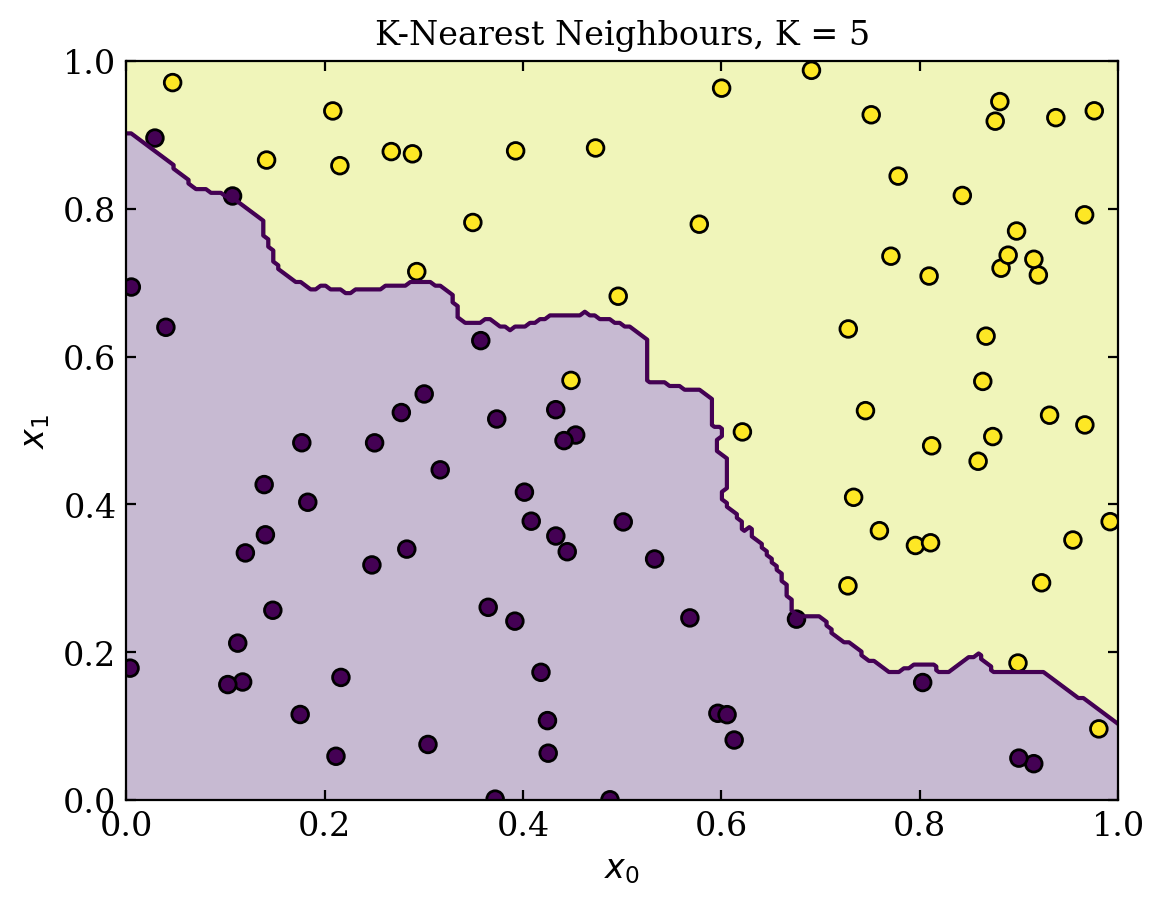

In [47]:
from sklearn.neighbors import KNeighborsClassifier

X = np.random.random((100,2))
y = (X[:,0] + X[:,1] > 1).astype(int)

knc = KNeighborsClassifier(5) # use 5 nearest neighbors
knc.fit(X,y)

y_pred = knc.predict(X)

xx, yy = np.meshgrid(
    np.linspace(0, 1, 200),
    np.linspace(0, 1, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
pred = knc.predict(grid).reshape(xx.shape)

plt.contourf(xx, yy, pred, alpha=0.3)
plt.contour(xx, yy, pred, levels=[0.5])

plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="black")

plt.xlabel("$x_0$")
plt.ylabel("$x_1$")
plt.title("K-Nearest Neighbours, K = 5")

plt.show()

We can also apply this to the star examples above:

completeness [[0.13868613 0.3649635  0.46715328 0.54014599]
 [0.00729927 0.24087591 0.37956204 0.54744526]]
contamination [[0.85606061 0.54954955 0.44347826 0.41732283]
 [0.88888889 0.44067797 0.23529412 0.25      ]]


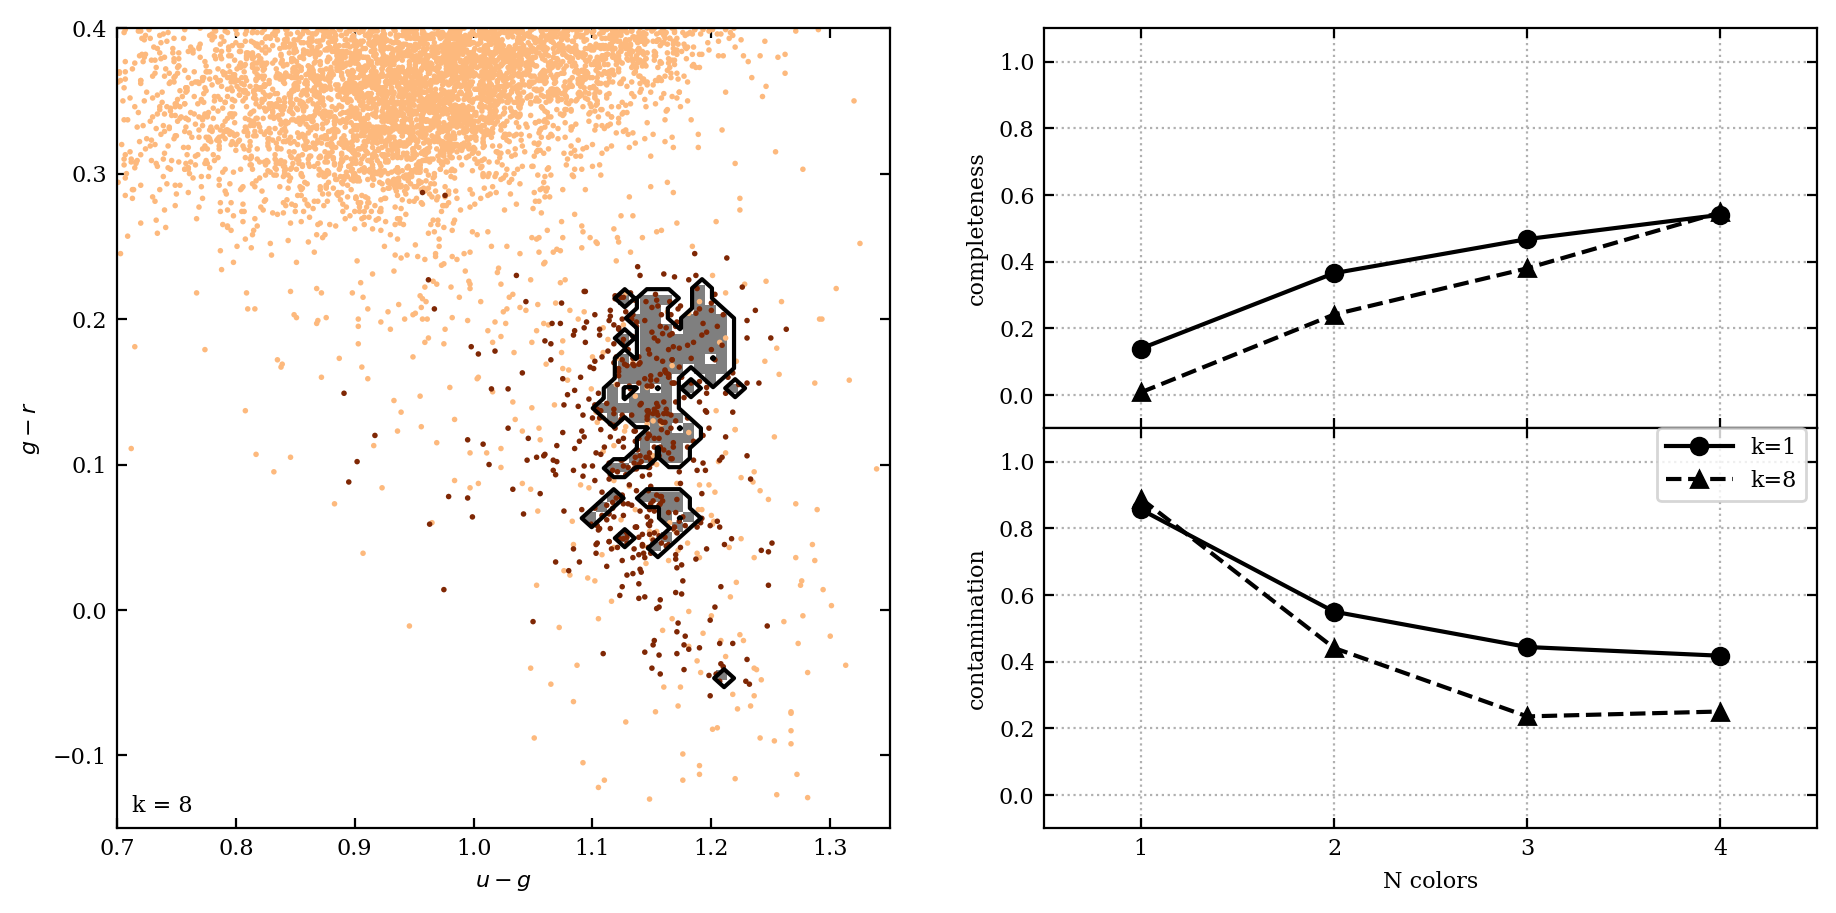

In [48]:
# Ivezic v2, Figure 9.7, edits by GTR
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from sklearn.neighbors import KNeighborsClassifier
from astroML.datasets import fetch_rrlyrae_combined
from astroML.utils import split_samples
from astroML.utils import completeness_contamination

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

#----------------------------------------------------------------------
# get data and split into training & testing sets
X, y = fetch_rrlyrae_combined()
X = X[:, [1, 0, 2, 3]]  # rearrange columns for better 1-color results
(X_train, X_test), (y_train, y_test) = split_samples(X, y, [0.75, 0.25],
                                                     random_state=0)

N_tot = len(y)
N_st = np.sum(y == 0)
N_rr = N_tot - N_st
N_train = len(y_train)
N_test = len(y_test)
N_plot = 5000 + N_rr

#----------------------------------------------------------------------
# perform Classification

classifiers = []
predictions = []
Ncolors = np.arange(1, X.shape[1] + 1)
kvals = [1, 8]

for k in kvals:
    classifiers.append([])
    predictions.append([])
    for nc in Ncolors:
        clf = KNeighborsClassifier(n_neighbors=k)
        clf.fit(X_train[:, :nc], y_train)
        y_pred = clf.predict(X_test[:, :nc])

        classifiers[-1].append(clf)
        predictions[-1].append(y_pred)

completeness, contamination = completeness_contamination(predictions, y_test)

print("completeness", completeness)
print("contamination", contamination)

#------------------------------------------------------------
# Compute the decision boundary
clf = classifiers[1][1]
xlim = (0.7, 1.35)
ylim = (-0.15, 0.4)

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 71),
                     np.linspace(ylim[0], ylim[1], 81))

Z = clf.predict(np.c_[yy.ravel(), xx.ravel()])
Z = Z.reshape(xx.shape)

#----------------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(10, 5))
fig.subplots_adjust(bottom=0.15, top=0.95, hspace=0.0,
                    left=0.1, right=0.95, wspace=0.2)

# left plot: data and decision boundary
ax = fig.add_subplot(121)
im = ax.scatter(X[-N_plot:, 1], X[-N_plot:, 0], c=y[-N_plot:],
                s=4, lw=0, cmap=plt.cm.Oranges, zorder=2)
im.set_clim(-0.5, 1)

im = ax.imshow(Z, origin='lower', aspect='auto',
               cmap=plt.cm.binary, zorder=1,
               extent=xlim + ylim)
im.set_clim(0, 2)

ax.contour(xx, yy, Z, [0.1], colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')

ax.text(0.02, 0.02, "k = %i" % kvals[1],
        transform=ax.transAxes)

# plot completeness vs Ncolors
ax = fig.add_subplot(222)

ax.plot(Ncolors, completeness[0], 'o-k', ms=6, label='k=%i' % kvals[0])
ax.plot(Ncolors, completeness[1], '^--k', ms=6, label='k=%i' % kvals[1])

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.NullFormatter())

ax.set_ylabel('completeness')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

# plot contamination vs Ncolors
ax = fig.add_subplot(224)
ax.plot(Ncolors, contamination[0], 'o-k', ms=6, label='k=%i' % kvals[0])
ax.plot(Ncolors, contamination[1], '^--k', ms=6, label='k=%i' % kvals[1])
ax.legend(loc='lower right',
          bbox_to_anchor=(1.0, 0.79))

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%i'))
ax.set_xlabel('N colors')
ax.set_ylabel('contamination')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

plt.show()

K = 1 is pretty bad, and K = 8 is meh, so how do we even pick K? We use our best friend Cross Validation. 

The code below finds this:

max score is for k=8


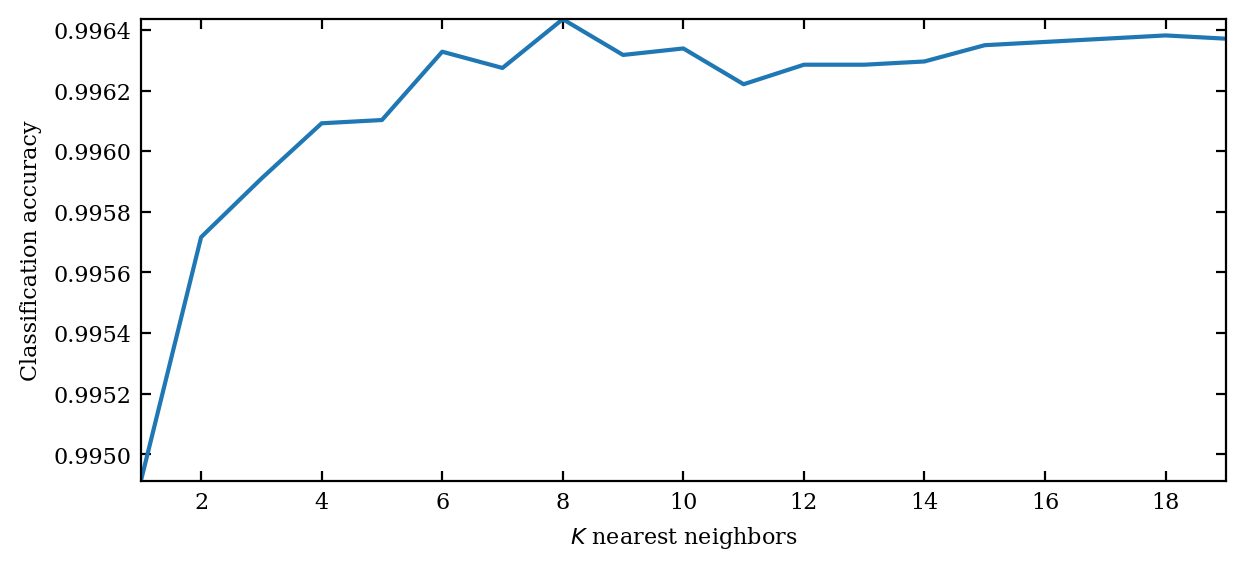

In [49]:
from sklearn.neighbors import KNeighborsClassifier
from astroML.datasets import fetch_rrlyrae_combined
from astroML.utils import completeness_contamination

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score

#----------------------------------------------------------------------
# get data and split into training & testing sets
X, y = fetch_rrlyrae_combined()
X = X[:, [1, 0, 2, 3]]  # rearrange columns for better 1-color results

#----------------------------------------------------------------------
# perform Classification
scores = []
kvals = np.arange(1,20)
for k in kvals:
    clf = KNeighborsClassifier(n_neighbors=k)
    CVpredk = cross_val_predict(clf, X, y)
    scores.append(accuracy_score(y, CVpredk)) 

print("max score is for k={:d}".format(kvals[np.argmax(scores)]))

# Plot number of neighbors vs score
fig = plt.figure(figsize=(7, 3))
u = np.arange(len(scores))+1
plt.plot(u,scores)
plt.xlabel('$K$ nearest neighbors')
plt.ylabel('Classification accuracy');

We can see why we chose K = 8.

In [50]:
from sklearn import metrics 

#print(k, nc)
print("accuracy:", metrics.accuracy_score(y_test, y_pred))
print("precision:", metrics.precision_score(y_test, y_pred))
print("recall:", metrics.recall_score(y_test, y_pred))

accuracy: 0.9962638495233187
precision: 0.75
recall: 0.5474452554744526
